### 🧱 CELL 1 — Import Libraries

In this step, we import all required libraries:

- `os` → for file and folder operations  
- `random` → to select random images  
- `numpy` → numerical operations  
- `matplotlib` → to display images  
- `PIL` → to open images  

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### 🧱 CELL 2 — Set Dataset Path

We define the location of our dataset using a relative path.

This allows our project to be portable and work on any system.

In [2]:
dataset_path = "../data/Garbage classification"

print("Dataset path set:", dataset_path)

Dataset path set: ../data/Garbage classification


### 🧱 CELL 3 — Load Classes

We list all class folders inside the dataset.

Each folder represents a category (label) for our model.

In [3]:
classes = os.listdir(dataset_path)
print("Classes:", classes)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 🧱 CELL 4 — Display One Image

We randomly select:
- a class
- an image inside that class

Then we display it to visually inspect the dataset.

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

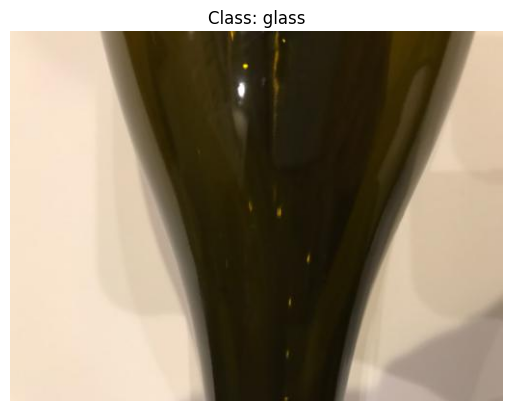

In [4]:
random_class = random.choice(classes)

class_path = os.path.join(dataset_path, random_class)

image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, image_name)

img = Image.open(image_path)

plt.imshow(img)
plt.title(f"Class: {random_class}")
plt.axis("off")

### 🧱 CELL 5 — Display Multiple Images

We display multiple random images from different classes.

This helps us understand variation and diversity in the dataset.

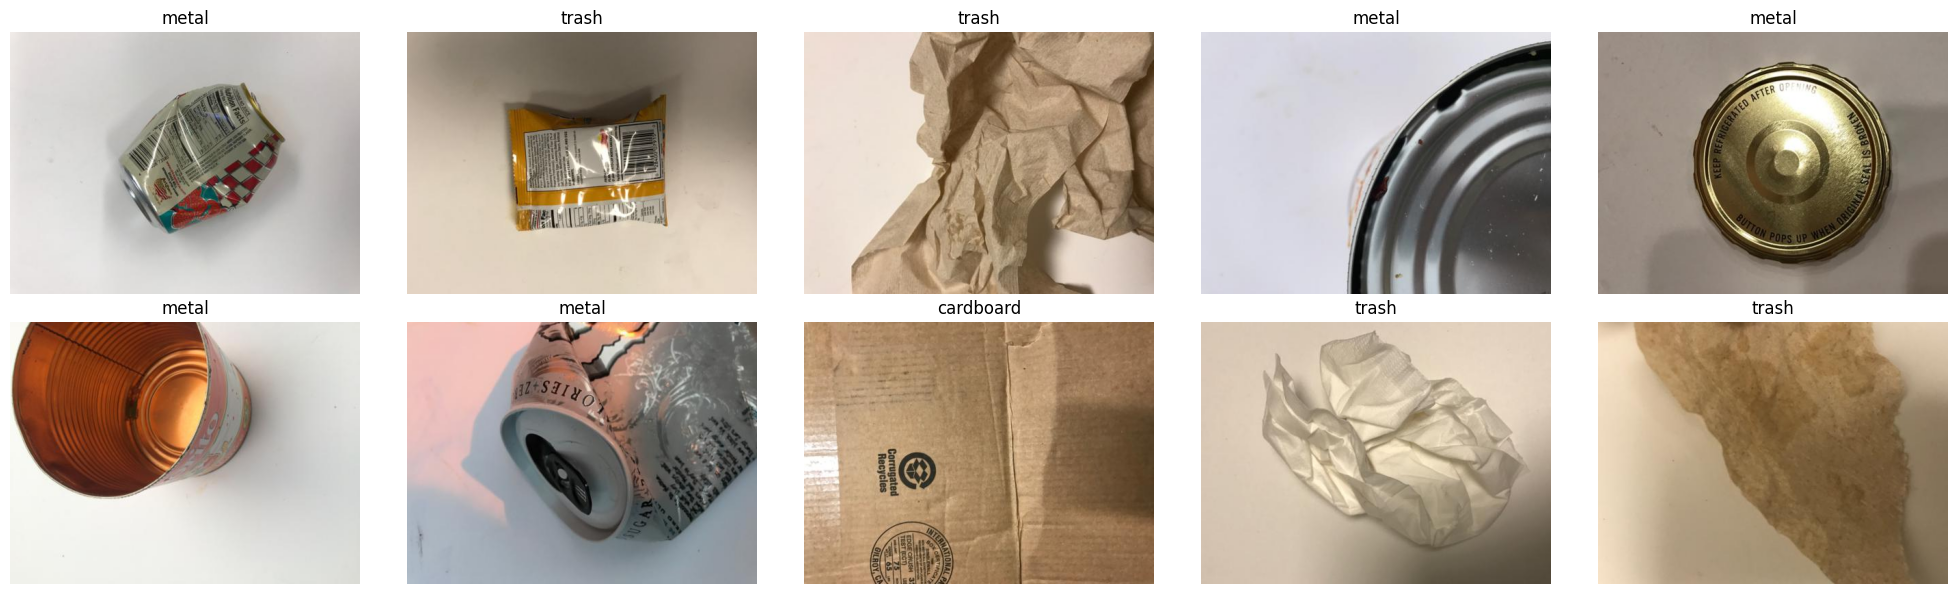

In [5]:
plt.figure(figsize=(20, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    random_class = random.choice(classes)
    class_path = os.path.join(dataset_path, random_class)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    img = Image.open(image_path)
    
    plt.imshow(img)
    plt.title(random_class)
    plt.axis("off")

plt.tight_layout()

### 🧱 CELL 6 — Count Images per Class

We count how many images exist in each category.

This helps identify class imbalance in the dataset.

In [6]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(class_path))
    class_counts[cls] = count

print(class_counts)

{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


### 🧱 CELL 7 — Visualize Class Distribution

In this step, we visualize the number of images in each class using a bar chart.

This helps us:
- understand dataset distribution  
- identify class imbalance  
- prepare for model training  

A balanced dataset is important because:
- models perform better when all classes have similar representation  
- imbalanced data may cause bias toward dominant classes  

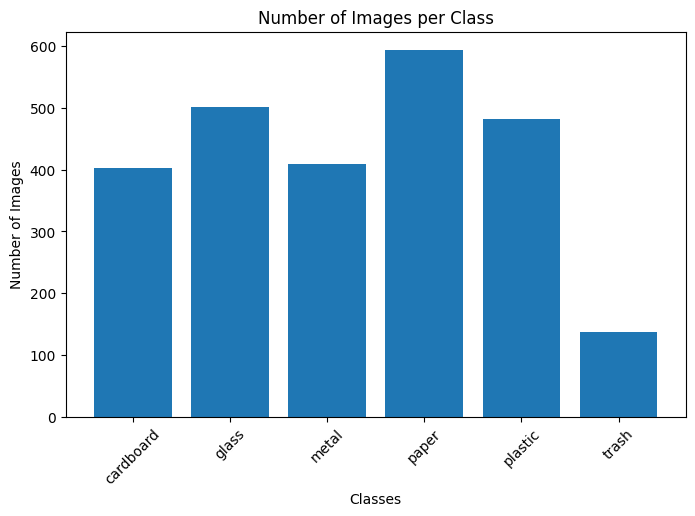

In [7]:
plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

### 🧱 CELL 8 — Import TensorFlow

In this step, we import TensorFlow.

TensorFlow is the deep learning library we will use to:
- load image data
- build the model
- train the model
- evaluate predictions

In [8]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 🧱 CELL 9 — Define Image Size and Batch Size

In this step, we define how images will be processed before training.

- Image size → all images will be resized to a fixed shape  
- Batch size → number of images processed at once  

Standard practice:
- 224 × 224 is commonly used in deep learning models  
- batch size of 32 balances speed and memory usage  

In [9]:
img_size = (224, 224)
batch_size = 32

print("Image size:", img_size)
print("Batch size:", batch_size)

Image size: (224, 224)
Batch size: 32


### 🧱 CELL 10 — Load Training Dataset

In this step, we load the dataset using TensorFlow.

TensorFlow will:
- read images from folders
- assign labels automatically based on folder names
- resize images to the defined size
- group images into batches

We also split the dataset:
- 80% → training data
- 20% → validation data

In [10]:
train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


### 🧱 CELL 11 — Load Validation Dataset

In this step, we load the validation dataset.

Validation data is used to test the model during training on images it has not learned from.

This helps us check whether the model is learning well or overfitting.

In [11]:
val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


### 🧱 CELL 12 — Check Class Names

In this step, we check the class names detected by TensorFlow.

These class names come directly from the folder names in the dataset.

In [12]:
class_names = train_data.class_names

print("Class names:", class_names)

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 🧱 CELL 13 — Visualize Batch of Images

In this step, we visualize a batch of images from the training dataset.

This shows how TensorFlow:
- loads images
- resizes them
- groups them into batches

This is important to verify that data is correctly prepared before training the model.

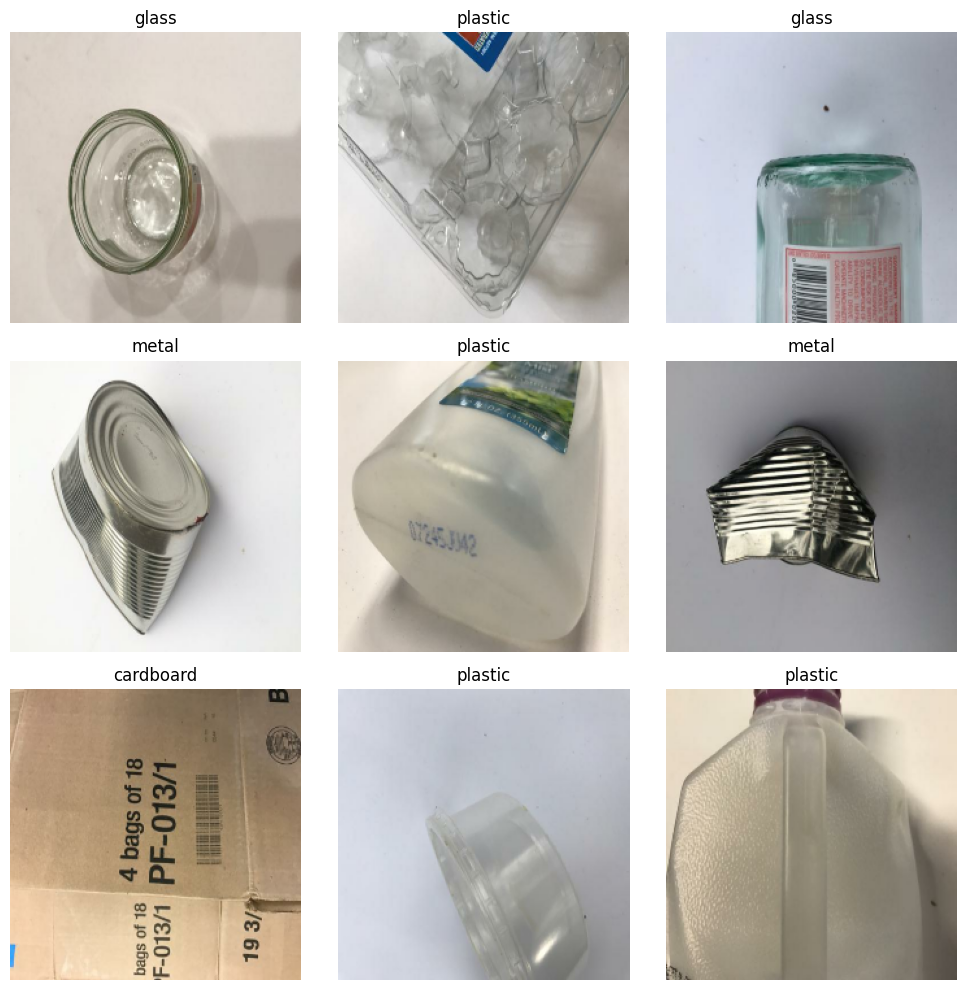

In [13]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()

### 🧱 CELL 14 — Normalize Image Pixels

In this step, we normalize image pixel values.

Images normally have pixel values from 0 to 255.

Neural networks train better when values are scaled between 0 and 1.

In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

print("Image pixels normalized between 0 and 1")

Image pixels normalized between 0 and 1


### 🧱 CELL 15 — Build CNN Model

In this step, we build a Convolutional Neural Network (CNN).

A CNN is commonly used for image classification because it can learn visual patterns such as:
- edges
- shapes
- textures
- object features

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.summary()

c:\AI-Portfolio\AI-Engineering-Portfolio\01-smart-waste-sorting\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### 🧱 CELL 16 — Compile Model

In this step, we configure how the model will learn.

We define:
- optimizer → how the model updates its weights  
- loss function → how errors are measured  
- metrics → how performance is evaluated  

For multi-class classification:
- we use "adam" optimizer  
- we use "sparse_categorical_crossentropy" loss  
- we track "accuracy"

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


### 🧱 CELL 17 — Train Model

In this step, we train the model.

The model will:
- learn patterns from training data  
- adjust weights to minimize error  
- validate performance on unseen data  

We train for a few epochs (iterations over the dataset).

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.3546 - loss: 1.7662 - val_accuracy: 0.4158 - val_loss: 1.4541
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - accuracy: 0.5064 - loss: 1.2766 - val_accuracy: 0.4436 - val_loss: 1.3045
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 288ms/step - accuracy: 0.5781 - loss: 1.1073 - val_accuracy: 0.5743 - val_loss: 1.1257
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.6503 - loss: 0.9395 - val_accuracy: 0.5525 - val_loss: 1.1439
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 277ms/step - accuracy: 0.7334 - loss: 0.7413 - val_accuracy: 0.5762 - val_loss: 1.1767


### 🧱 CELL 18 — Evaluate Model

In this step, we evaluate the model performance on validation data.

This tells us:
- how well the model performs on unseen data  
- whether the model is learning correctly  

We check:
- loss → error value  
- accuracy → percentage of correct predictions  

In [18]:
val_loss, val_accuracy = model.evaluate(val_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5762 - loss: 1.1767
Validation Loss: 1.176732063293457
Validation Accuracy: 0.5762376189231873


### 🧱 CELL 19 — Plot Training Performance

In this step, we visualize how the model performed during training.

We plot:
- training accuracy  
- validation accuracy  
- training loss  
- validation loss  

This helps us understand:
- if the model is improving  
- if the model is overfitting or underfitting  

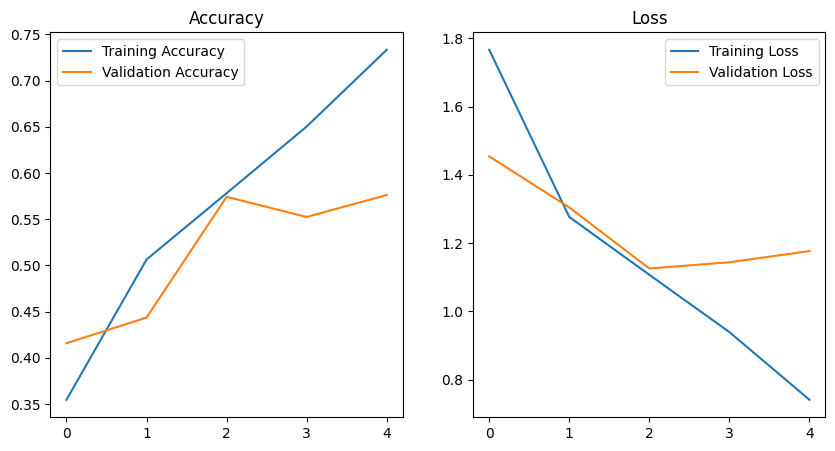

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

### 🧱 CELL 20 — Reduce Overfitting (Dropout)

In this step, we improve the model by adding Dropout layers.

Dropout helps:
- prevent overfitting  
- improve generalization  
- make the model more robust  

It works by randomly turning off neurons during training.

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

### 🧱 CELL 21 — Compile Improved Model

After modifying the model by adding Dropout, we compile it again.

Compiling prepares the new model for training by defining:
- optimizer
- loss function
- evaluation metric

In [32]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully")

Improved model compiled successfully


### 🧱 CELL 22 — Retrain Improved Model

In this step, we retrain the improved CNN model.

This model includes Dropout to reduce overfitting.

We will compare the new training results with the earlier model.

In [23]:
history_dropout = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.2992 - loss: 1.6863 - val_accuracy: 0.3842 - val_loss: 1.4335
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.4288 - loss: 1.4098 - val_accuracy: 0.3663 - val_loss: 1.4725
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 279ms/step - accuracy: 0.4965 - loss: 1.2773 - val_accuracy: 0.4911 - val_loss: 1.3182
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 276ms/step - accuracy: 0.5504 - loss: 1.1720 - val_accuracy: 0.5545 - val_loss: 1.1972
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.6088 - loss: 1.0511 - val_accuracy: 0.5980 - val_loss: 1.0618


### 🧱 CELL 23 — Plot Improved Model Performance

In this step, we visualize the training and validation performance after adding Dropout.

This helps us compare:
- original model vs improved model  
- overfitting behavior  

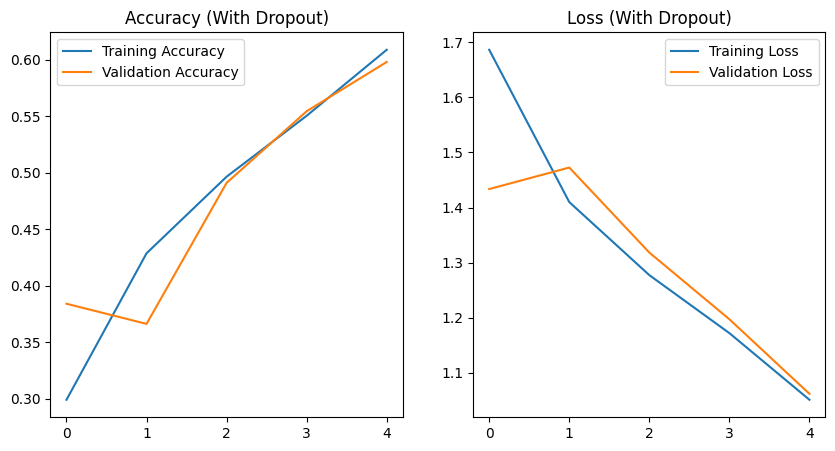

In [24]:
acc = history_dropout.history['accuracy']
val_acc = history_dropout.history['val_accuracy']

loss = history_dropout.history['loss']
val_loss = history_dropout.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy (With Dropout)')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss (With Dropout)')

plt.show()

### 🧱 CELL 24 — Final Model Evaluation

In this step, we evaluate the final performance of the improved model.

We use the validation dataset to measure how well the model performs on unseen data.

The key metric we observe is:
- validation accuracy → percentage of correct predictions

This gives us the final estimate of model performance.

In [25]:
val_loss, val_accuracy = model.evaluate(val_data)

print("Final Validation Accuracy:", val_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5980 - loss: 1.0618
Final Validation Accuracy: 0.5980197787284851


### 🧱 CELL 25 — Test Model on One Image

In this step, we test the trained model on one image from the validation data.

The model will:
- take an image
- predict probabilities for all classes
- choose the class with the highest probability

We compare:
- actual label
- predicted label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


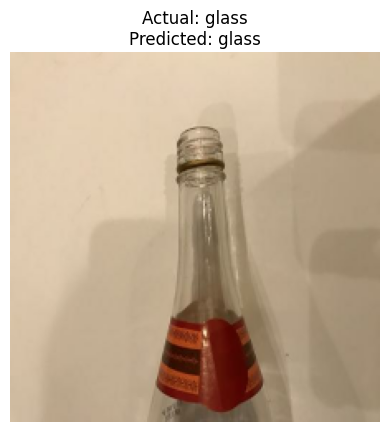

In [28]:
for images, labels in val_data.take(1):
    image = images[0]
    actual_label = labels[0]

    prediction = model.predict(tf.expand_dims(image, axis=0))
    predicted_label = np.argmax(prediction[0])

    plt.imshow(image.numpy())
    plt.title(
        f"Actual: {class_names[actual_label]}\nPredicted: {class_names[predicted_label]}"
    )
    plt.axis("off")

### 🧱 CELL 26 — Train Model Longer

In this step, we continue training the improved model for more epochs.

Training longer may help the model learn better patterns, but we must watch for overfitting.

We will compare:
- training accuracy
- validation accuracy
- training loss
- validation loss

In [29]:
history_longer = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.6686 - loss: 0.9057 - val_accuracy: 0.5010 - val_loss: 1.3820
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 275ms/step - accuracy: 0.7043 - loss: 0.8074 - val_accuracy: 0.6297 - val_loss: 1.0652
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.7695 - loss: 0.6446 - val_accuracy: 0.5901 - val_loss: 1.1531
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.8126 - loss: 0.5378 - val_accuracy: 0.6079 - val_loss: 1.1988
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - accuracy: 0.8457 - loss: 0.4185 - val_accuracy: 0.6218 - val_loss: 1.2488
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - accuracy: 0.8754 - loss: 0.3619 - val_accuracy: 0.6218 - val_loss: 1.3519
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.8986 - loss: 0.3041 - val_accuracy: 0.6297 - val_loss: 1.3111
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - accuracy: 0.8838 - loss: 0.3355 - val_accu

### 🧱 CELL 27 — Prevent Overfitting (Early Stopping)

In this step, we use EarlyStopping.

EarlyStopping automatically stops training when validation performance stops improving.

This prevents:
- overfitting
- unnecessary training

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_early = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.3378 - loss: 1.6967 - val_accuracy: 0.4277 - val_loss: 1.3912
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.4649 - loss: 1.3686 - val_accuracy: 0.4950 - val_loss: 1.2576
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - accuracy: 0.5361 - loss: 1.2072 - val_accuracy: 0.5347 - val_loss: 1.1954
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.5663 - loss: 1.1409 - val_accuracy: 0.5703 - val_loss: 1.0512
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 277ms/step - accuracy: 0.6192 - loss: 0.9859 - val_accuracy: 0.6059 - val_loss: 1.1425
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.6612 - loss: 0.9313 - val_accuracy: 0.6059 - val_loss: 1.0579


### 🧱 CELL 28 — Build MobileNetV2 Transfer Learning Model

In this step, we improve the model using transfer learning.

MobileNetV2 is a pretrained computer vision model that already learned useful image features from a large image dataset.

We use MobileNetV2 as a feature extractor and add our own final classification layer for the 6 waste classes.

In [36]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 🧱 CELL 29 — Compile MobileNet Model

In this step, we compile the MobileNetV2 transfer learning model.

We use:
- Adam optimizer
- sparse categorical crossentropy loss
- accuracy as the metric

In [37]:
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNet model compiled successfully")

MobileNet model compiled successfully


### 🧱 CELL 30 — Train MobileNet Model

In this step, we train the MobileNetV2 transfer learning model.

Since MobileNet already has learned features, training will:
- be faster
- generalize better
- improve accuracy compared to the basic CNN

We also use EarlyStopping to prevent overfitting.

In [38]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.5292 - loss: 1.2319 - val_accuracy: 0.6812 - val_loss: 0.8122
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.7245 - loss: 0.7065 - val_accuracy: 0.7644 - val_loss: 0.6538
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.7898 - loss: 0.5823 - val_accuracy: 0.7723 - val_loss: 0.6142
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.8170 - loss: 0.5135 - val_accuracy: 0.7881 - val_loss: 0.5694
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.8269 - loss: 0.4722 - val_accuracy: 0.8040 - val_loss: 0.5446
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.8462 - loss: 0.4220 - val_accuracy: 0.8178 - val_loss: 0.5143
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.8605 - loss: 0.3942 - val_accuracy: 0.8238 - val_loss: 0.5165
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.8684 - loss: 0.3704 - val_accu

In [39]:
mobilenet_model.save("../models/smart_waste_mobilenet.keras")

print("MobileNet model saved successfully")

MobileNet model saved successfully
